In [14]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [28]:
class Bmistate(TypedDict):

    weight : float
    height : float
    bmi : float
    cale : str


In [ ]:
def bmi(state : Bmistate):

    weight = state['weight']
    height = state['height']

    bmi = weight/(height**2)

    state['bmi'] = bmi 
    return state

In [29]:
def label(state : Bmistate):

    bmi = state['bmi']

    if bmi < 18.5:
        state['cale'] = 'underweight'
    elif 18.5 <= bmi < 25:
        state['cale'] = 'normal'
    elif 25 <= bmi < 30:
        state['cale'] = 'overweight'
    else:
        state['cale'] = 'obese'
    return state

In [36]:
graph = StateGraph(Bmistate)

graph.add_node('cal', bmi)
graph.add_node('label',label)

graph.add_edge(START ,'cal')
graph.add_edge('cal','label')
graph.add_edge('label',END)

G = graph.compile()


In [37]:
a = {'weight':40,'height':3.5}
output = G.invoke(a)

print(output)


{'weight': 40, 'height': 3.5, 'bmi': 3.2653061224489797, 'cale': 'underweight'}


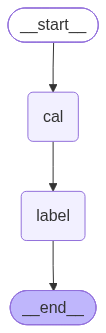

In [34]:

graph.compile()